# Análisis Exploratorio de Datos - E-commerce - InsightLab

Este notebook desarrolla el análisis exploratorio del dataset **Indian E-Commerce Customer Behavior & Purchase**.  
El objetivo del EDA es comprender el comportamiento de los usuarios dentro de la plataforma, identificar patrones asociados a la compra y detectar variables útiles para un modelo de predicción de intención de compra y promociones personalizadas.

## Objetivo del análisis

El análisis busca responder preguntas relacionadas con el problema de negocio:

- ¿Qué proporción de sesiones termina en compra?
- ¿Qué proporción de usuarios abandona el carrito?
- ¿Qué variables de navegación, descuento, producto o sesión se relacionan con la conversión?
- ¿Qué segmentos de comportamiento podrían recibir promociones o experiencias personalizadas?

## Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from cargar_datos import cargar_datos

## Carga de datos

La carga del dataset se realiza desde el archivo `cargar_datos.py`.  
Se mantiene la lógica de carga separada del análisis para que este notebook se concentre en el EDA.

In [2]:
data = cargar_datos()

Archivo cargado: Ecommerce.csv
Cantidad de filas: 25000
Cantidad de columnas: 29


In [3]:
data.head()

,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
0,1803,0,28-11-2024,2,1,2,894,6,651.57,1,...,1,0,1,28,11,3,0,Long,0.000000,209
1,7964,1,25-09-2024,2,0,4,844,2,945.27,4,...,1,0,2,25,9,2,0,Long,0.000000,213
2,6890,2,31-05-2024,1,1,0,865,0,400.44,4,...,1,0,2,31,5,4,1,Short,0.000000,10
3,4949,3,30-01-2024,1,0,2,851,3,1268.54,2,...,10,4,1,30,1,1,3,Very Long,0.305504,46
4,4896,4,25-02-2024,1,1,5,794,3,880.81,3,...,1,0,1,25,2,6,3,Very Short,0.000000,118


## Exploración inicial

En esta etapa se revisa la estructura general del dataset: cantidad de filas, columnas, tipos de datos y primeras observaciones.

In [4]:
print(f"Cantidad de filas: {data.shape[0]}")
print(f"Cantidad de columnas: {data.shape[1]}")

Cantidad de filas: 25000
Cantidad de columnas: 29


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              25000 non-null  int64  
 1   session_id               25000 non-null  int64  
 2   visit_date               25000 non-null  object 
 3   device_type              25000 non-null  int64  
 4   user_type                25000 non-null  int64  
 5   marketing_channel        25000 non-null  int64  
 6   product_id               25000 non-null  int64  
 7   product_category         25000 non-null  int64  
 8   unit_price               25000 non-null  float64
 9   quantity                 25000 non-null  int64  
 10  discount_percent         25000 non-null  int64  
 11  discount_amount          25000 non-null  float64
 12  revenue                  25000 non-null  float64
 13  pages_viewed             25000 non-null  int64  
 14  time_on_site_sec      

In [6]:
data.columns.tolist()

['customer_id',
 'session_id',
 'visit_date',
 'device_type',
 'user_type',
 'marketing_channel',
 'product_id',
 'product_category',
 'unit_price',
 'quantity',
 'discount_percent',
 'discount_amount',
 'revenue',
 'pages_viewed',
 'time_on_site_sec',
 'added_to_cart',
 'purchased',
 'cart_abandoned',
 'rating',
 'review_text',
 'review_helpful_votes',
 'payment_method',
 'visit_day',
 'visit_month',
 'visit_weekday',
 'visit_season',
 'session_duration_bucket',
 'revenue_normalized',
 'location']

## Descripción de las variables disponibles

El dataset contiene información de identificación de clientes y sesiones, fecha de visita, dispositivo, canal de marketing, producto, precio, descuento, navegación, carrito, compra, reseñas, método de pago y ubicación.

Para el proyecto, la variable objetivo será:

`purchased`: indica si la sesión terminó en compra.

También existen variables importantes para el análisis de negocio:

- `added_to_cart`: indica si el usuario agregó productos al carrito.
- `cart_abandoned`: indica si el carrito fue abandonado.
- `discount_percent` y `discount_amount`: representan descuentos aplicados.
- `pages_viewed` y `time_on_site_sec`: representan intensidad de navegación.
- `revenue`: ingresos generados por la sesión.

## Conversión de fecha

La columna `visit_date` viene como texto. Se convierte a formato fecha para poder analizar comportamiento temporal.

In [7]:
data["visit_date"] = pd.to_datetime(
    data["visit_date"],
    format="%d-%m-%Y",
    errors="coerce"
)

data[["visit_date", "visit_day", "visit_month", "visit_weekday", "visit_season"]].head()

,visit_date,visit_day,visit_month,visit_weekday,visit_season
0,2024-11-28,28,11,3,0
1,2024-09-25,25,9,2,0
2,2024-05-31,31,5,4,1
3,2024-01-30,30,1,1,3
4,2024-02-25,25,2,6,3


## Revisión de valores nulos

In [8]:
print(f"\nValores nulos por columna:\n")
resumen_nulos = pd.DataFrame({
    "nulos": data.isnull().sum(),
    "porcentaje": data.isnull().mean() * 100
}).sort_values(by="porcentaje", ascending=False)

resumen_nulos


Valores nulos por columna:



,nulos,porcentaje
customer_id,0,0.0
session_id,0,0.0
visit_date,0,0.0
device_type,0,0.0
user_type,0,0.0
marketing_channel,0,0.0
product_id,0,0.0
product_category,0,0.0
unit_price,0,0.0
quantity,0,0.0


El análisis de nulos permite determinar si existen columnas incompletas que requieran tratamiento antes del modelado.

## Revisión de duplicados

In [9]:
duplicados = data.duplicated().sum()

print(f"Cantidad de registros duplicados: {duplicados}")

Cantidad de registros duplicados: 0


## Clasificación de variables

Aunque muchas columnas están codificadas como números, no todas deben interpretarse como variables numéricas continuas.  
Por ejemplo, `device_type`, `marketing_channel`, `product_category` o `payment_method` representan categorías codificadas.

In [10]:
TARGET = "purchased"

columnas_id = [
    "customer_id",
    "session_id",
    "product_id"
]

columnas_categoricas = [
    "device_type",
    "user_type",
    "marketing_channel",
    "product_category",
    "added_to_cart",
    "purchased",
    "cart_abandoned",
    "rating",
    "review_text",
    "payment_method",
    "visit_day",
    "visit_month",
    "visit_weekday",
    "visit_season",
    "session_duration_bucket",
    "location"
]

columnas_numericas = [
    "unit_price",
    "quantity",
    "discount_percent",
    "discount_amount",
    "revenue",
    "pages_viewed",
    "time_on_site_sec",
    "review_helpful_votes",
    "revenue_normalized"
]

print("Columnas identificadoras:")
print(columnas_id)

print("\nColumnas categóricas/codificadas:")
print(columnas_categoricas)

print("\nColumnas numéricas:")
print(columnas_numericas)

Columnas identificadoras:
['customer_id', 'session_id', 'product_id']

Columnas categóricas/codificadas:
['device_type', 'user_type', 'marketing_channel', 'product_category', 'added_to_cart', 'purchased', 'cart_abandoned', 'rating', 'review_text', 'payment_method', 'visit_day', 'visit_month', 'visit_weekday', 'visit_season', 'session_duration_bucket', 'location']

Columnas numéricas:
['unit_price', 'quantity', 'discount_percent', 'discount_amount', 'revenue', 'pages_viewed', 'time_on_site_sec', 'review_helpful_votes', 'revenue_normalized']


## Estadísticas descriptivas

Primero se revisan las variables numéricas para entender escalas, dispersión, mínimos, máximos y posibles valores atípicos.

In [33]:
data[columnas_numericas].describe()

,unit_price,quantity,discount_percent,discount_amount,revenue,pages_viewed,time_on_site_sec,review_helpful_votes,revenue_normalized
count,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000
mean,782.319010,2.489040,8.99880,174.997669,404.646762,12.535840,903.262920,5.52080,0.051290
std,476.612168,1.114563,9.26364,269.005411,1022.391774,6.929762,518.676202,12.33629,0.129591
min,50.050000,1.000000,0.00000,0.000000,0.000000,1.000000,10.000000,0.00000,0.000000
25%,395.222500,1.000000,0.00000,0.000000,0.000000,7.000000,453.000000,0.00000,0.000000
50%,691.725000,2.000000,10.00000,65.815000,0.000000,13.000000,903.000000,0.00000,0.000000
75%,1096.842500,3.000000,15.00000,240.355000,0.000000,19.000000,1355.000000,0.00000,0.000000
max,1999.830000,4.000000,30.00000,2388.260000,7889.360000,24.000000,1799.000000,49.00000,1.000000


## Distribución de la variable objetivo

La variable `purchased` indica si una sesión terminó en compra.  
Esta distribución permite evaluar el balance del problema de clasificación.

In [12]:
distribucion_target = pd.DataFrame({
    "cantidad": data[TARGET].value_counts(),
    "porcentaje": data[TARGET].value_counts(normalize=True).multiply(100).round(2)
})

distribucion_target

,cantidad,porcentaje
purchased,,
0,19384,77.54
1,5616,22.46


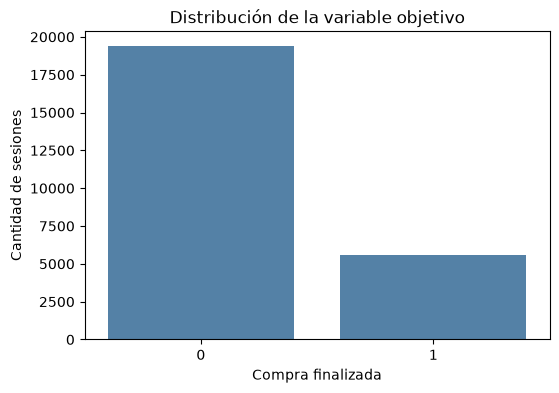

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=data,
    x=TARGET,
    color="steelblue"
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Compra finalizada")
plt.ylabel("Cantidad de sesiones")
plt.show()

## Análisis univariado de variables numéricas

Se visualizan distribuciones y boxplots de las variables numéricas principales.  
Esto permite detectar asimetrías, concentración de valores y posibles outliers.

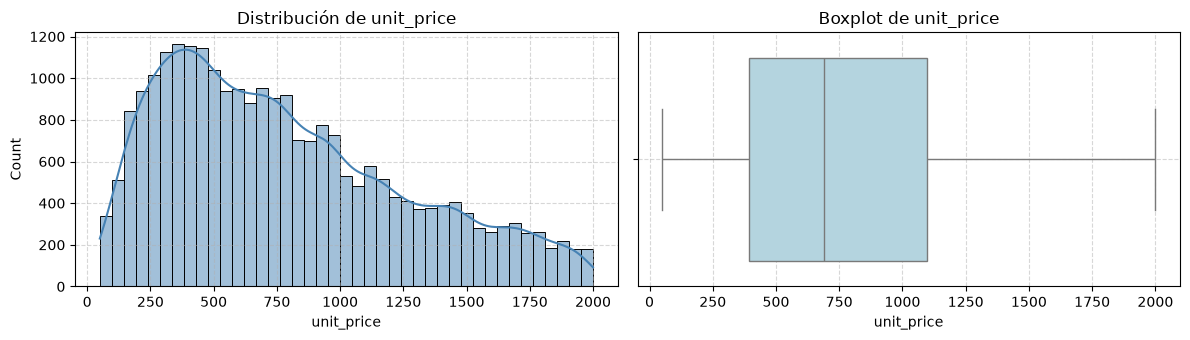

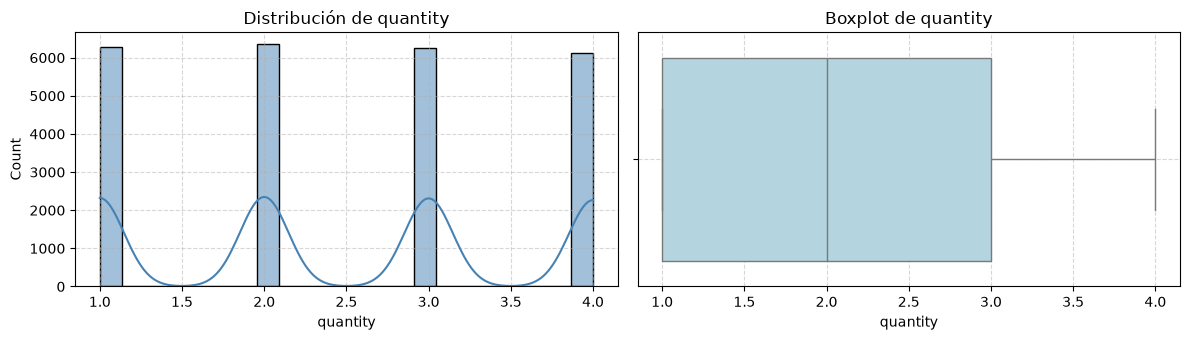

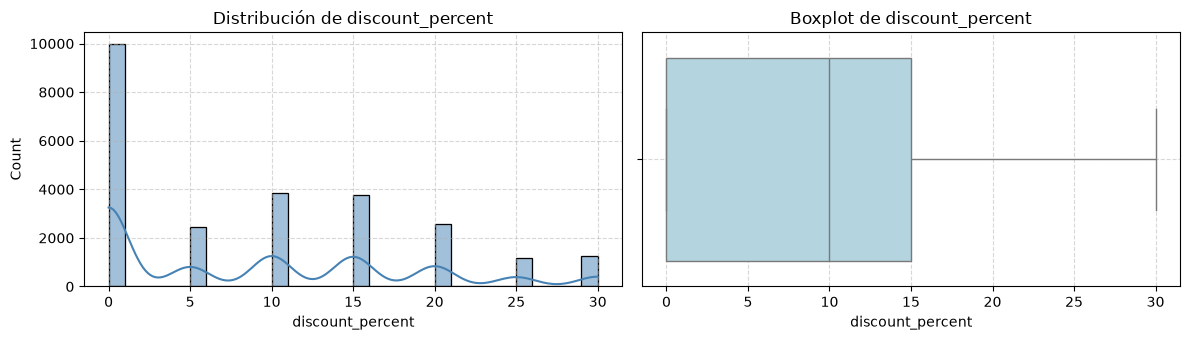

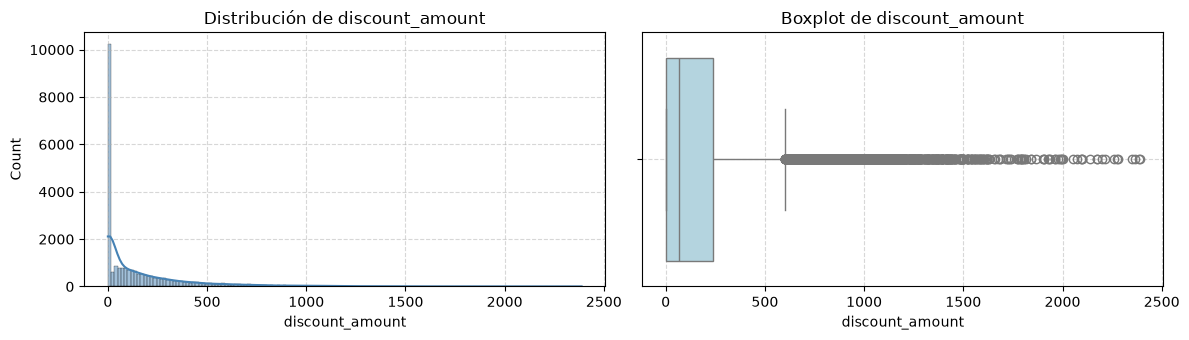

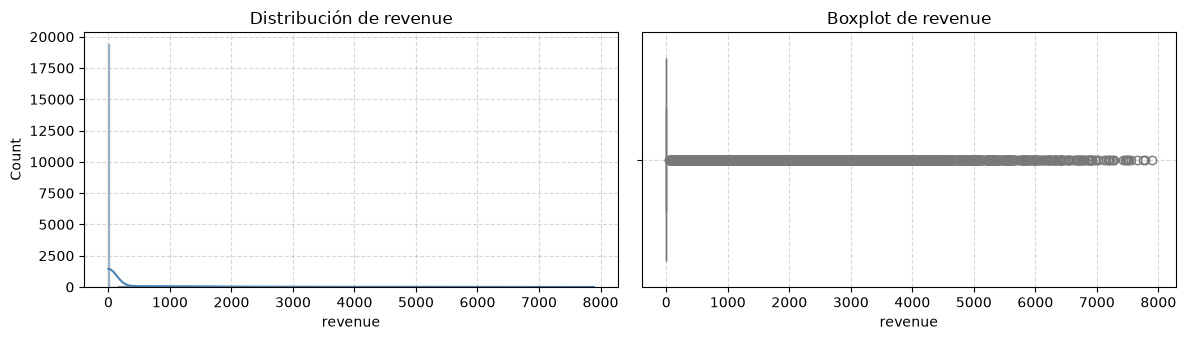

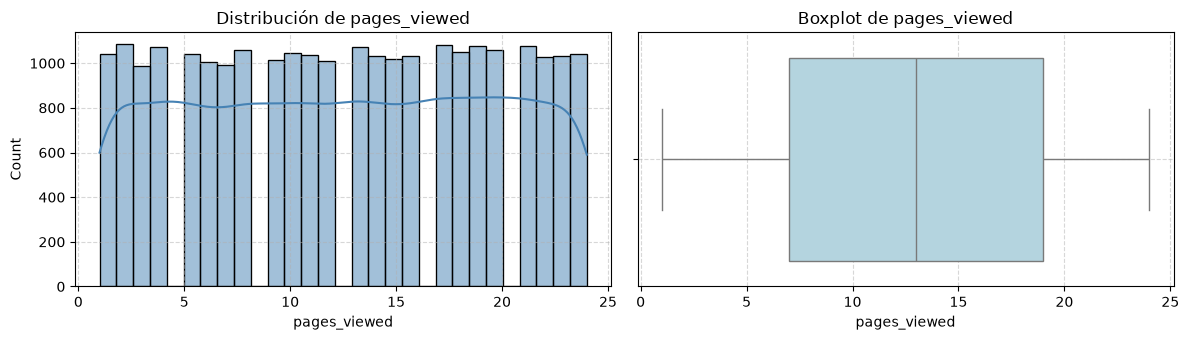

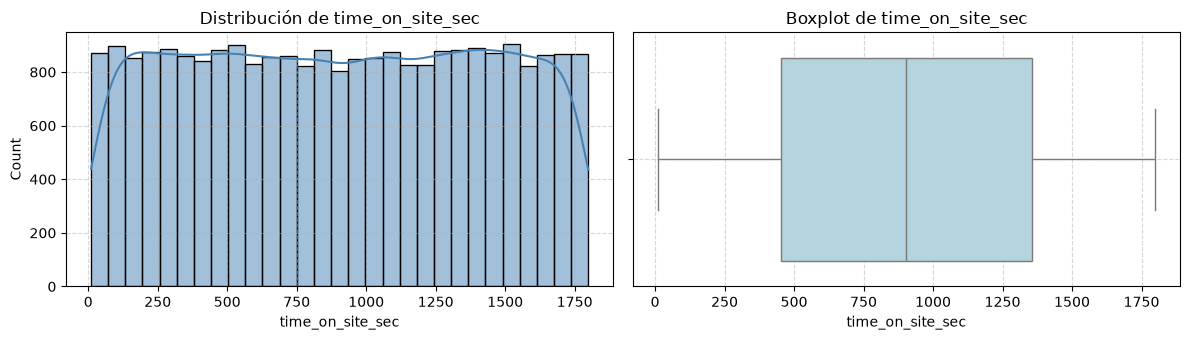

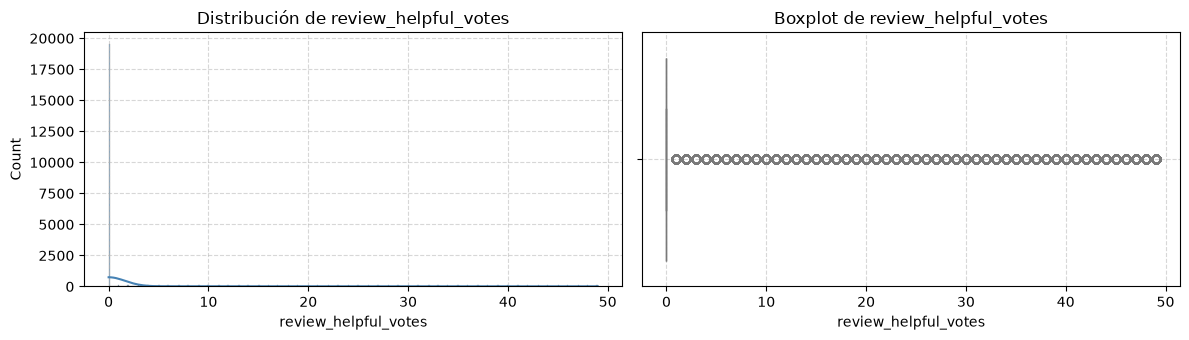

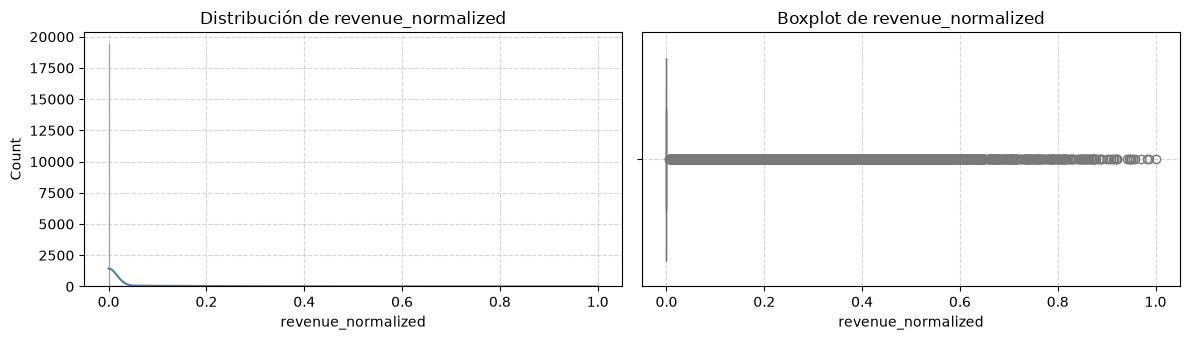

In [14]:
for columna in columnas_numericas:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

    sns.histplot(
        data=data,
        x=columna,
        kde=True,
        ax=axes[0],
        color="steelblue"
    )
    axes[0].set_title(f"Distribución de {columna}")
    axes[0].grid(True, linestyle="--", alpha=0.5)

    sns.boxplot(
        data=data,
        x=columna,
        ax=axes[1],
        color="lightblue"
    )
    axes[1].set_title(f"Boxplot de {columna}")
    axes[1].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

## Análisis de variables categóricas

Se revisa la distribución de las principales variables categóricas o codificadas.  
Al estar codificadas numéricamente, los valores representan clases y no magnitudes.

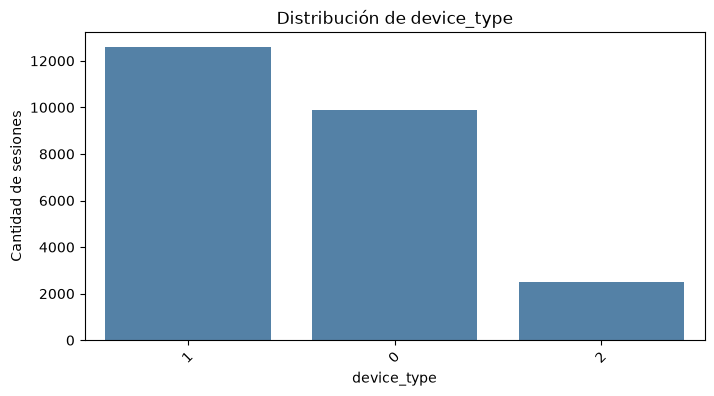

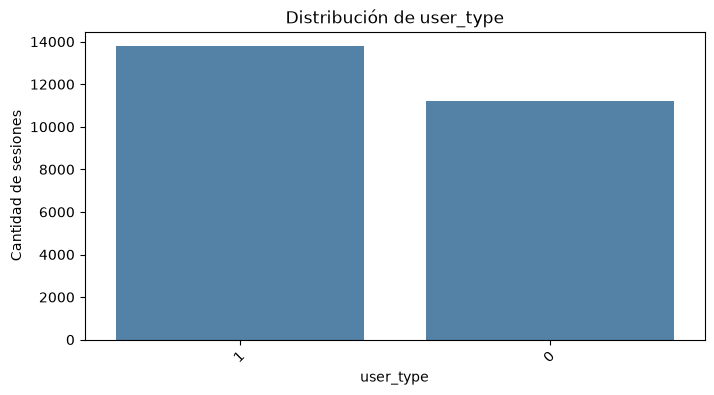

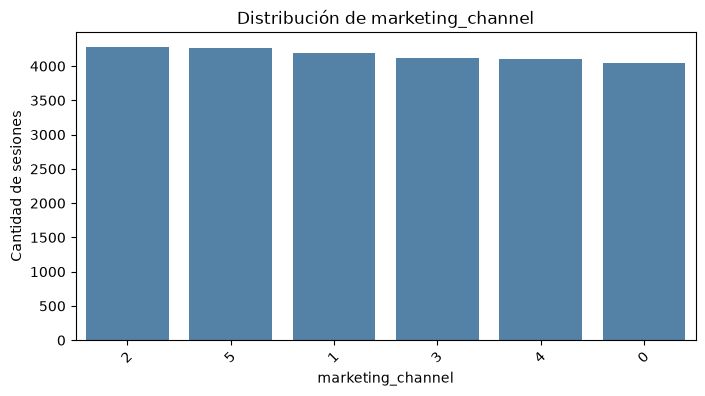

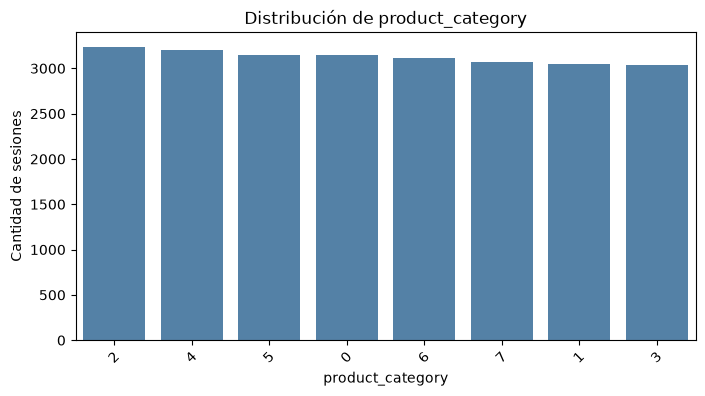

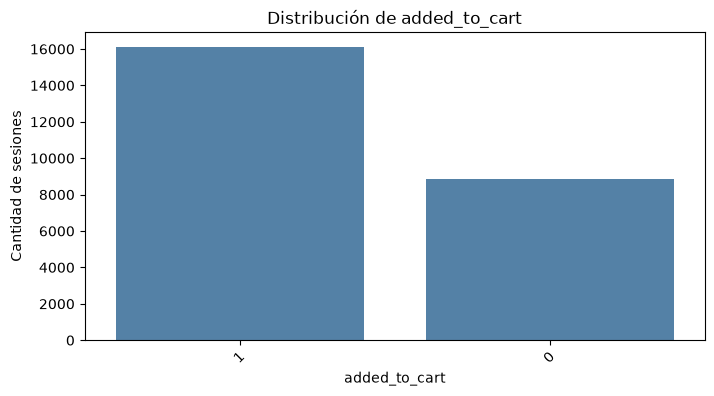

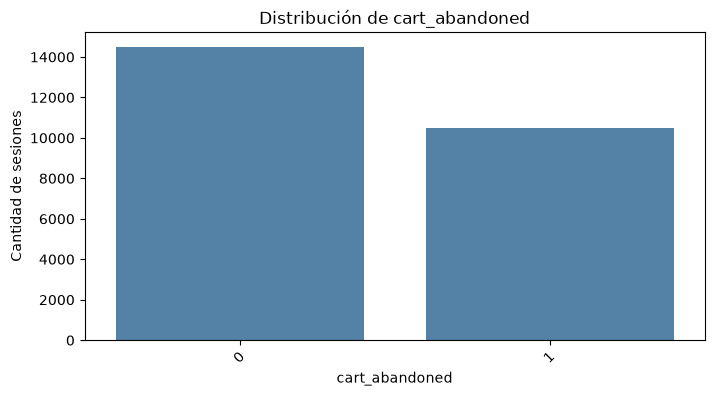

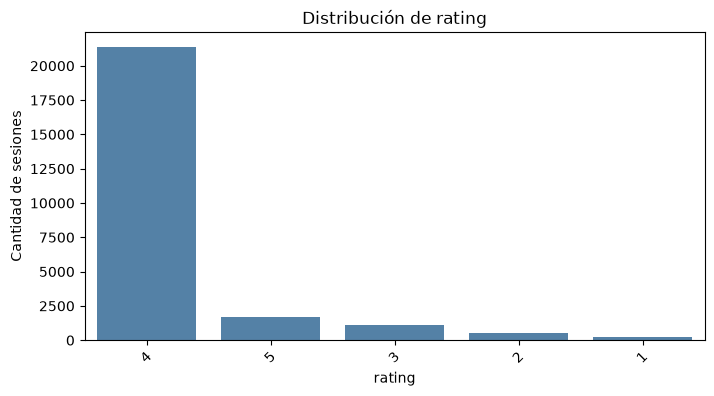

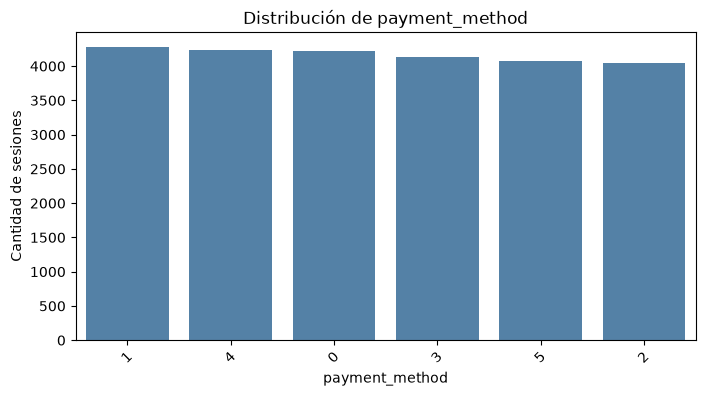

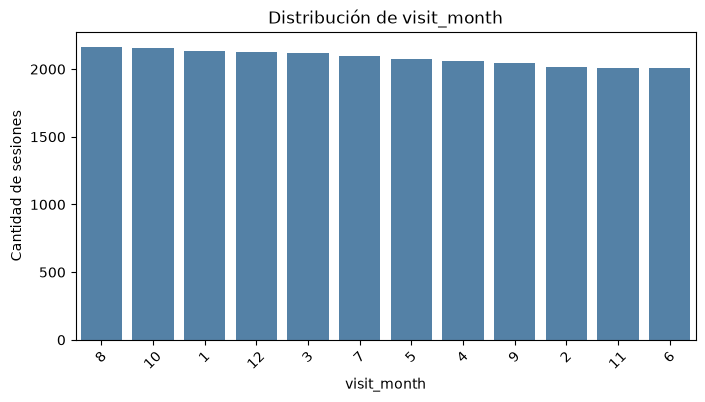

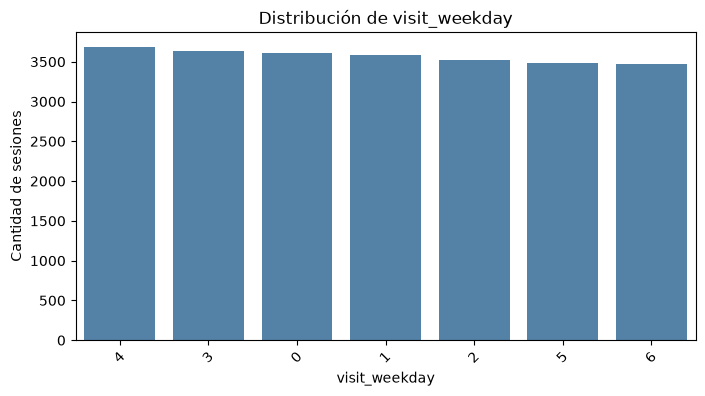

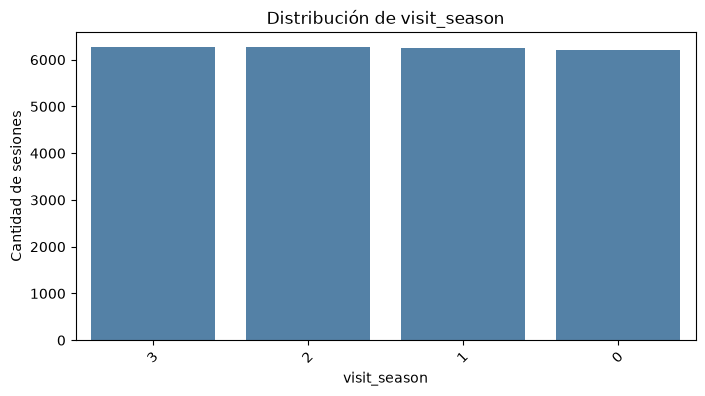

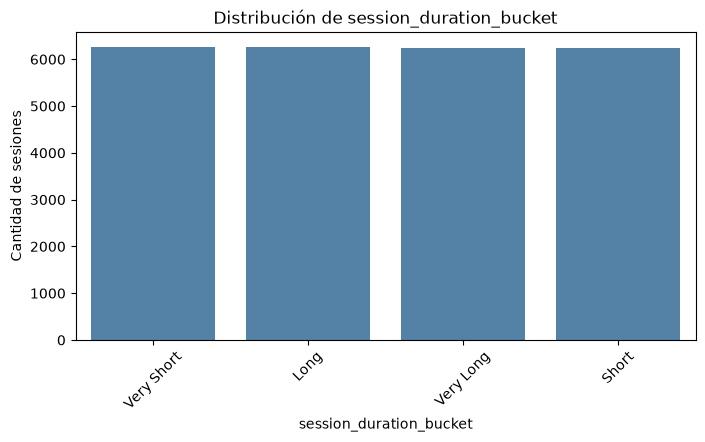

In [15]:
categoricas_para_graficar = [
    "device_type",
    "user_type",
    "marketing_channel",
    "product_category",
    "added_to_cart",
    "cart_abandoned",
    "rating",
    "payment_method",
    "visit_month",
    "visit_weekday",
    "visit_season",
    "session_duration_bucket"
]

for columna in categoricas_para_graficar:
    plt.figure(figsize=(8, 4))

    orden = data[columna].value_counts().index

    sns.countplot(
        data=data,
        x=columna,
        order=orden,
        color="steelblue"
    )

    plt.title(f"Distribución de {columna}")
    plt.xlabel(columna)
    plt.ylabel("Cantidad de sesiones")
    plt.xticks(rotation=45)
    plt.show()

## Tasa de conversión por variables categóricas

Se calcula la tasa de conversión promedio para distintas variables categóricas.  
Esto permite detectar categorías, canales, dispositivos o períodos con mejor desempeño comercial.

In [16]:
def graficar_conversion_por_categoria(df, columna, target=TARGET, top=None):
    conversion = (
        df.groupby(columna)[target]
        .mean()
        .sort_values(ascending=False)
    )

    if top is not None:
        conversion = conversion.head(top)
    
    display(conversion.multiply(100).round(2).to_frame("tasa_conversion_%"))

    plt.figure(figsize=(8, 4))

    sns.barplot(
        x=conversion.index.astype(str),
        y=conversion.values * 100,
        color="steelblue"
    )

    plt.title(f"Tasa de conversión según {columna}")
    plt.xlabel(columna)
    plt.ylabel("Tasa de conversión (%)")
    plt.xticks(rotation=45)
    plt.show()

,tasa_conversion_%
device_type,
2,23.20
0,22.46
1,22.32


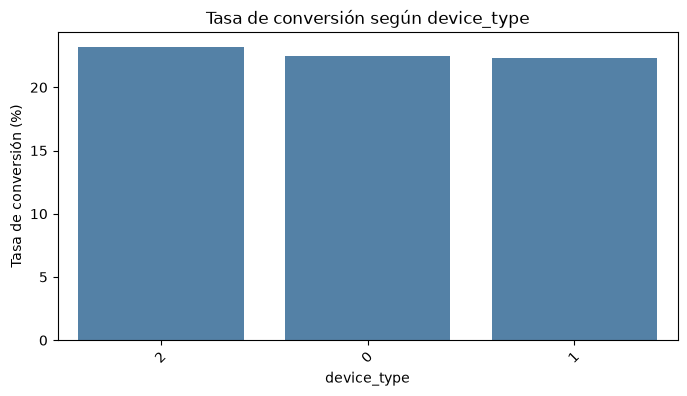

,tasa_conversion_%
user_type,
1,25.65
0,18.55


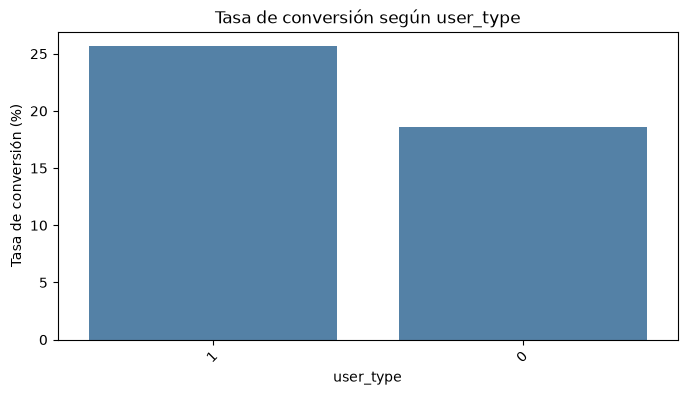

,tasa_conversion_%
marketing_channel,
5,23.60
0,22.72
3,22.64
1,22.12
2,22.03
4,21.66


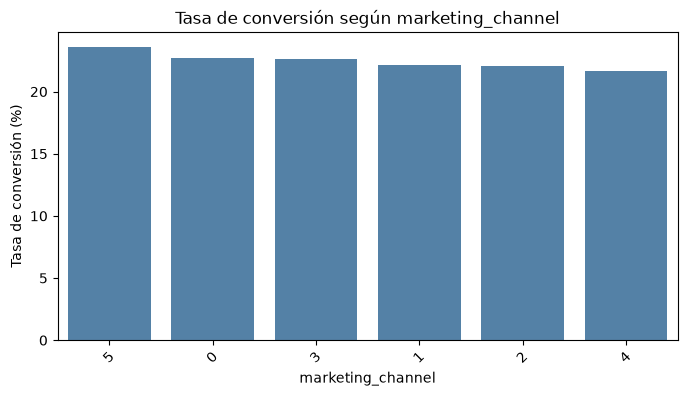

,tasa_conversion_%
product_category,
6,24.68
5,23.12
4,22.69
7,22.58
0,22.28
2,22.27
1,21.26
3,20.76


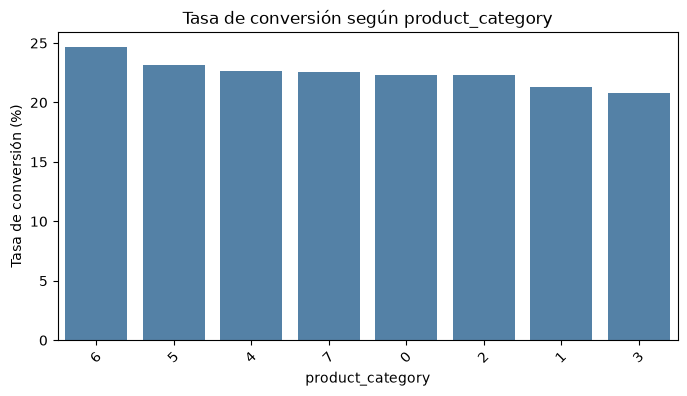

,tasa_conversion_%
rating,
1,100.00
2,100.00
3,100.00
5,100.00
4,9.33


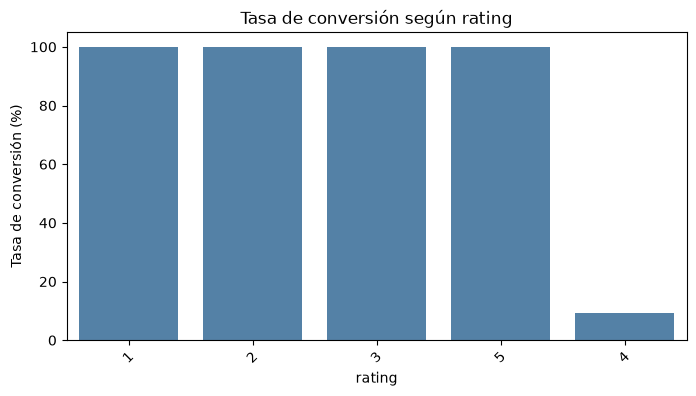

,tasa_conversion_%
payment_method,
2,23.20
3,22.92
1,22.89
5,22.42
4,22.20
0,21.17


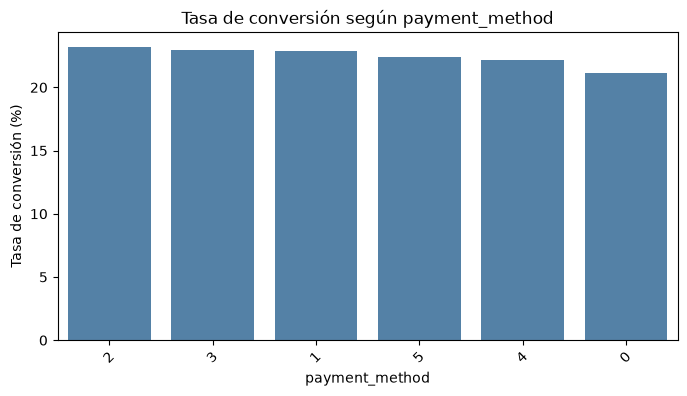

,tasa_conversion_%
session_duration_bucket,
Long,23.62
Very Long,23.22
Short,22.79
Very Short,20.24


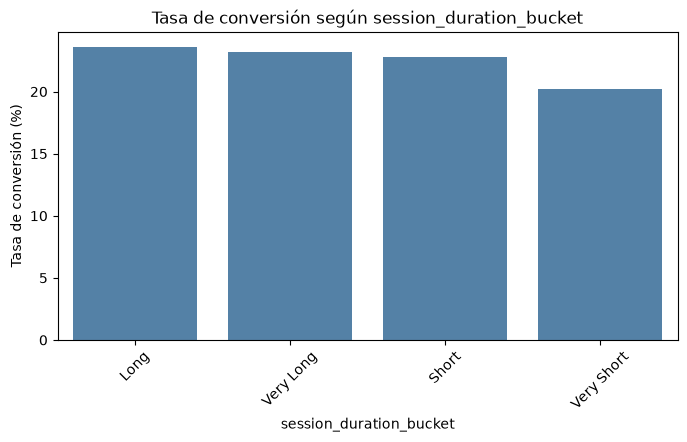

In [17]:
for columna in [
    "device_type",
    "user_type",
    "marketing_channel",
    "product_category",
    "rating",
    "payment_method",
    "session_duration_bucket"
]:
    graficar_conversion_por_categoria(data, columna)

## Análisis de descuentos

El descuento es central para el proyecto porque las promociones personalizadas serán una de las acciones comerciales propuestas.

In [18]:
data["tuvo_descuento"] = data["discount_percent"] > 0

conversion_descuento = (
    data.groupby("tuvo_descuento")[TARGET]
    .mean()
    .multiply(100)
)

conversion_descuento

tuvo_descuento
False    22.430751
True     22.486034
Name: purchased, dtype: float64

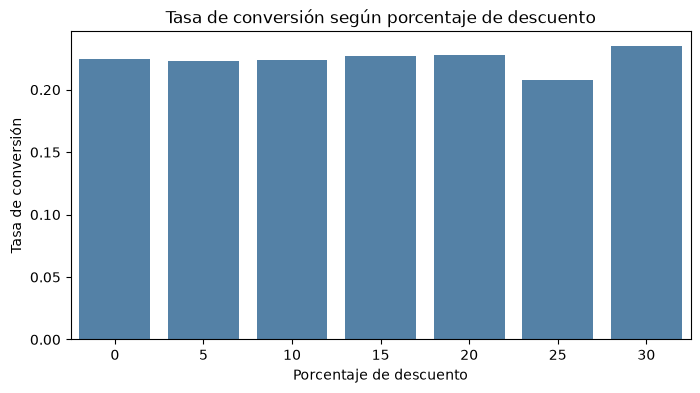

In [19]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=data,
    x="discount_percent",
    y=TARGET,
    estimator=np.mean,
    errorbar=None,
    color="steelblue"
)

plt.title("Tasa de conversión según porcentaje de descuento")
plt.xlabel("Porcentaje de descuento")
plt.ylabel("Tasa de conversión")
plt.show()

Este análisis permite observar si los descuentos se asocian a una mayor probabilidad de compra. En etapas posteriores, esta información ayudará a definir reglas de promociones personalizadas.

## Análisis de navegación

Se evalúa si la intensidad de navegación se relaciona con la conversión.

In [20]:
data["tiempo_por_pagina"] = (
    data["time_on_site_sec"] / data["pages_viewed"].replace(0, np.nan)
)

data.groupby(TARGET)[[
    "pages_viewed",
    "time_on_site_sec",
    "tiempo_por_pagina"
]].mean().round(2)

,pages_viewed,time_on_site_sec,tiempo_por_pagina
purchased,,,
0,12.51,895.61,141.23
1,12.62,929.69,142.70


Una mayor navegación puede indicar interés, pero también indecisión. Por eso estas variables deben interpretarse junto con carrito, descuento y resultado de compra.

## Análisis temporal

Se analiza la conversión por mes, día de la semana y temporada para detectar posibles patrones temporales.

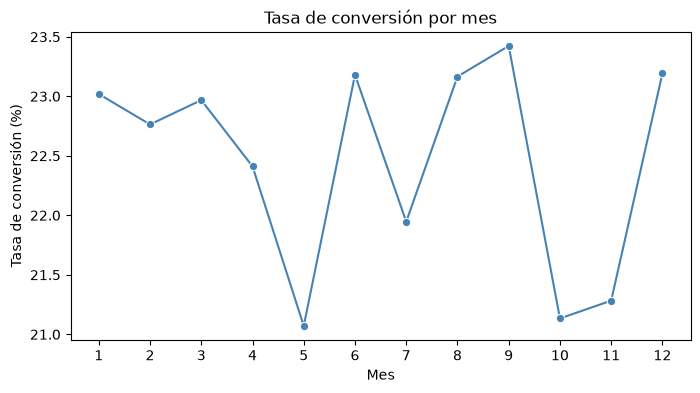

In [21]:
conversion_mes = (
    data.groupby("visit_month")[TARGET]
    .mean()
    .multiply(100)
)

plt.figure(figsize=(8, 4))

sns.lineplot(
    x=conversion_mes.index,
    y=conversion_mes.values,
    marker="o",
    color="steelblue"
)

plt.title("Tasa de conversión por mes")
plt.xlabel("Mes")
plt.ylabel("Tasa de conversión (%)")
plt.xticks(range(1, 13))
plt.show()

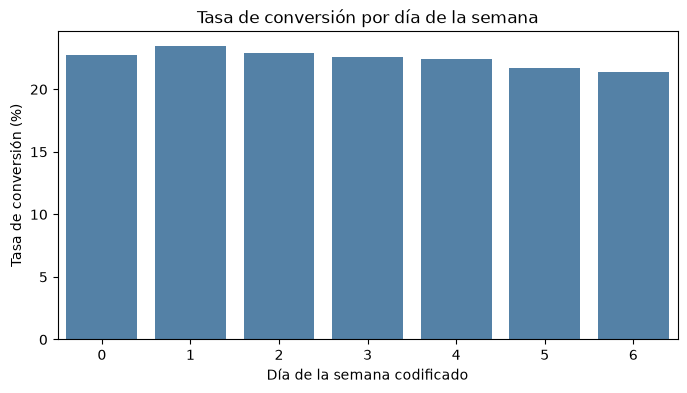

In [22]:
conversion_weekday = (
    data.groupby("visit_weekday")[TARGET]
    .mean()
    .multiply(100)
)

plt.figure(figsize=(8, 4))

sns.barplot(
    x=conversion_weekday.index.astype(str),
    y=conversion_weekday.values,
    color="steelblue"
)

plt.title("Tasa de conversión por día de la semana")
plt.xlabel("Día de la semana codificado")
plt.ylabel("Tasa de conversión (%)")
plt.show()

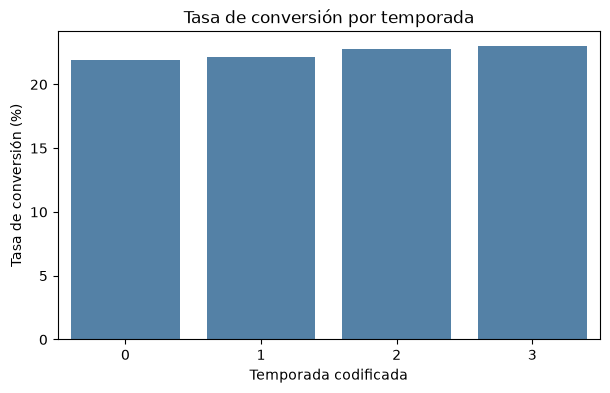

In [23]:
conversion_season = (
    data.groupby("visit_season")[TARGET]
    .mean()
    .multiply(100)
)

plt.figure(figsize=(7, 4))

sns.barplot(
    x=conversion_season.index.astype(str),
    y=conversion_season.values,
    color="steelblue"
)

plt.title("Tasa de conversión por temporada")
plt.xlabel("Temporada codificada")
plt.ylabel("Tasa de conversión (%)")
plt.show()

## Análisis de productos y categorías

Se revisan categorías y productos desde una perspectiva comercial: conversión, ingresos y abandono.

In [24]:
categoria_resumen = (
    data.groupby("product_category")
    .agg(
        sesiones=("session_id", "count"),
        conversion=("purchased", "mean"),
        abandono_carrito=("cart_abandoned", "mean"),
        ingresos_totales=("revenue", "sum"),
        ingreso_promedio=("revenue", "mean"),
        precio_promedio=("unit_price", "mean")
    )
    .sort_values(by="ingresos_totales", ascending=False)
)

categoria_resumen["conversion"] = categoria_resumen["conversion"] * 100
categoria_resumen["abandono_carrito"] = categoria_resumen["abandono_carrito"] * 100

categoria_resumen.round(2)

,sesiones,conversion,abandono_carrito,ingresos_totales,ingreso_promedio,precio_promedio
product_category,,,,,,
2,3237,22.27,40.93,2037576.79,629.46,1238.58
6,3112,24.68,40.42,1930885.22,620.46,1131.58
5,3149,23.12,43.03,1729167.16,549.12,997.96
3,3040,20.76,41.61,1293649.90,425.54,898.41
7,3073,22.58,42.34,1089617.52,354.58,671.48
0,3142,22.28,42.74,880077.03,280.10,579.68
1,3043,21.26,42.23,702788.87,230.95,455.72
4,3204,22.69,42.73,452406.57,141.20,275.25


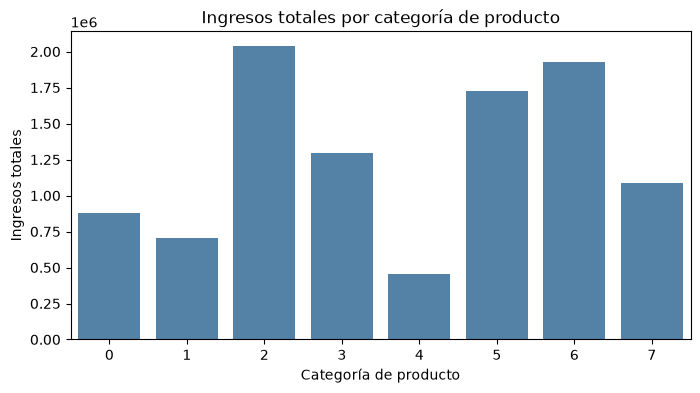

In [25]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=categoria_resumen.reset_index(),
    x="product_category",
    y="ingresos_totales",
    color="steelblue"
)

plt.title("Ingresos totales por categoría de producto")
plt.xlabel("Categoría de producto")
plt.ylabel("Ingresos totales")
plt.show()

In [26]:
top_productos_ingresos = (
    data.groupby("product_id")
    .agg(
        sesiones=("session_id", "count"),
        compras=("purchased", "sum"),
        ingresos_totales=("revenue", "sum"),
        conversion=("purchased", "mean")
    )
    .sort_values(by="ingresos_totales", ascending=False)
    .head(10)
)

top_productos_ingresos["conversion"] = top_productos_ingresos["conversion"] * 100

top_productos_ingresos.round(2)

,sesiones,compras,ingresos_totales,conversion
product_id,,,,
130,29,12,35975.88,41.38
292,41,13,33794.75,31.71
806,32,13,32446.56,40.62
49,31,9,32122.48,29.03
453,27,13,31456.73,48.15
696,41,11,30775.59,26.83
175,34,10,30099.90,29.41
686,43,13,30001.75,30.23
634,29,9,29627.73,31.03


Este análisis servirá para asociar promociones o recomendaciones comerciales a categorías y productos con mayor potencial de conversión o mayor abandono.

## Matriz de correlación

Se calcula la correlación entre variables numéricas.  
Para interpretar el modelo de compra hay que tener cuidado con variables posteriores a la compra, como `revenue` y `revenue_normalized`, porque pueden generar fuga de información si se usan como predictoras.

In [27]:
# Correlación con la variable objetivo
print("Correlación con variable objetivo:\n")

correlations = (
    data.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(ascending=False)
    .round(2)
)

print(correlations)

Correlación con variable objetivo:

review_helpful_votes    0.83
revenue_normalized      0.74
revenue                 0.74
review_text             0.63
added_to_cart           0.40
user_type               0.08
time_on_site_sec        0.03
product_category        0.02
product_id              0.01
visit_season            0.01
unit_price              0.01
visit_day               0.01
pages_viewed            0.01
payment_method          0.00
marketing_channel       0.00
quantity                0.00
discount_amount         0.00
device_type             0.00
tiempo_por_pagina       0.00
session_id              0.00
discount_percent        0.00
tuvo_descuento          0.00
customer_id            -0.00
location               -0.00
visit_month            -0.00
visit_weekday          -0.01
rating                 -0.18
cart_abandoned         -0.46
Name: purchased, dtype: float64


Matriz de Correlación:
 


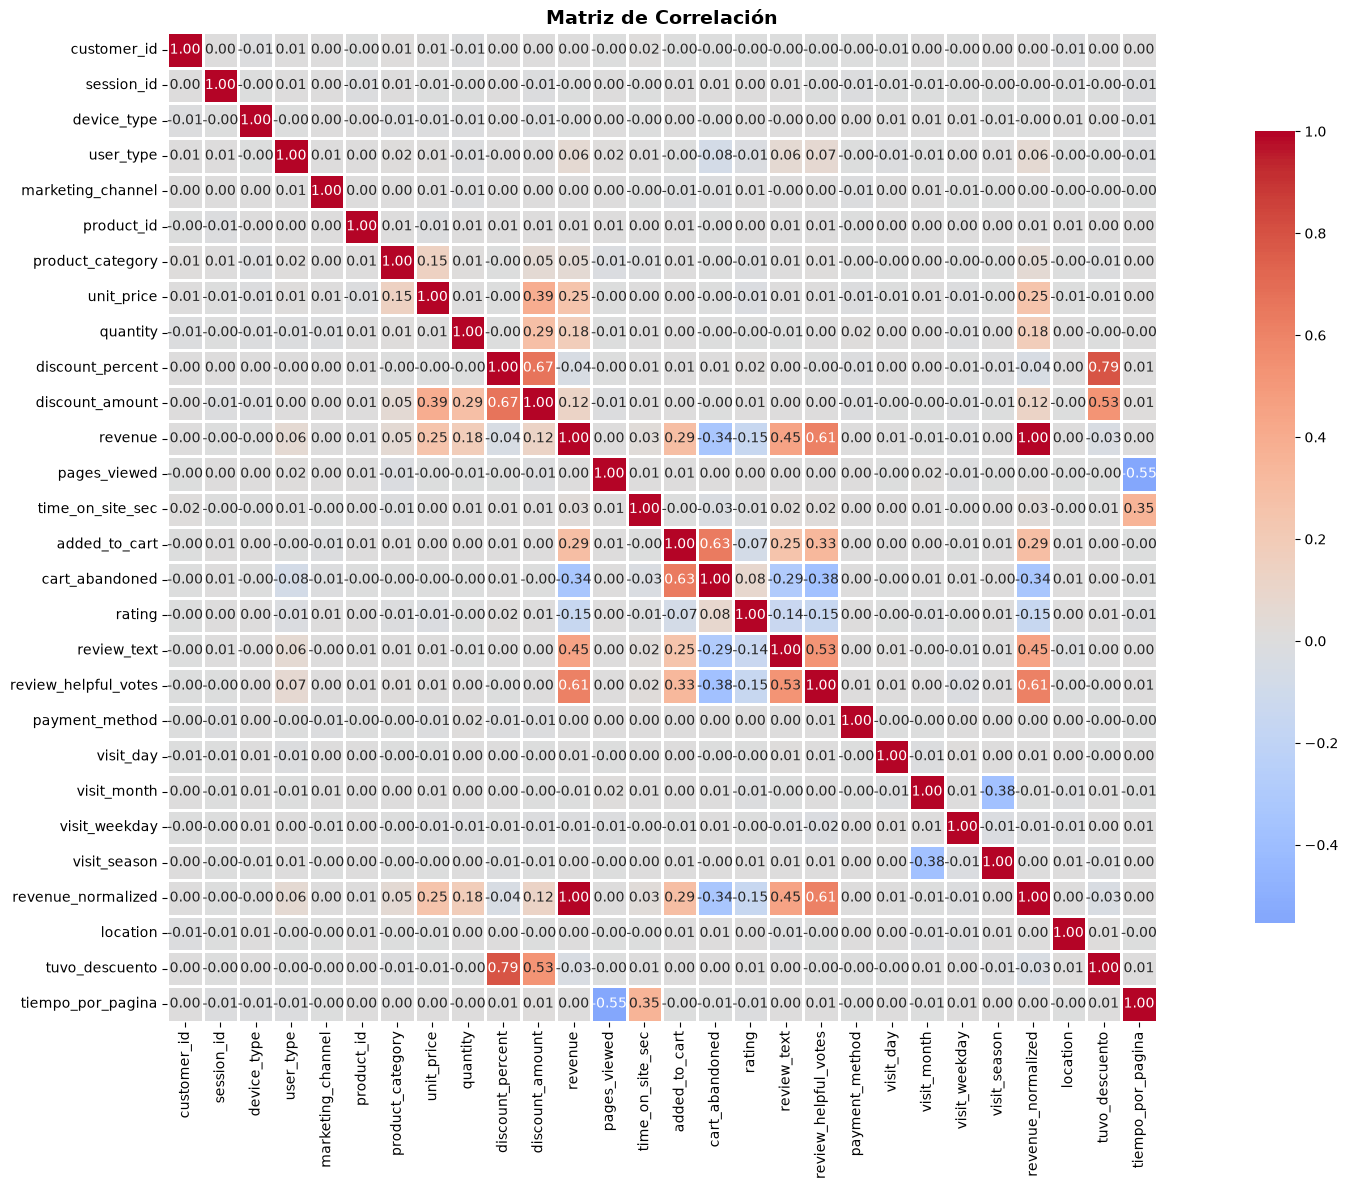

In [28]:
# Evaluación de Multicolinealidad
print("Matriz de Correlación:\n ")

correlation = data.drop(TARGET, axis = 1).corr(numeric_only=True)

plt.figure(figsize=(20, 12))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

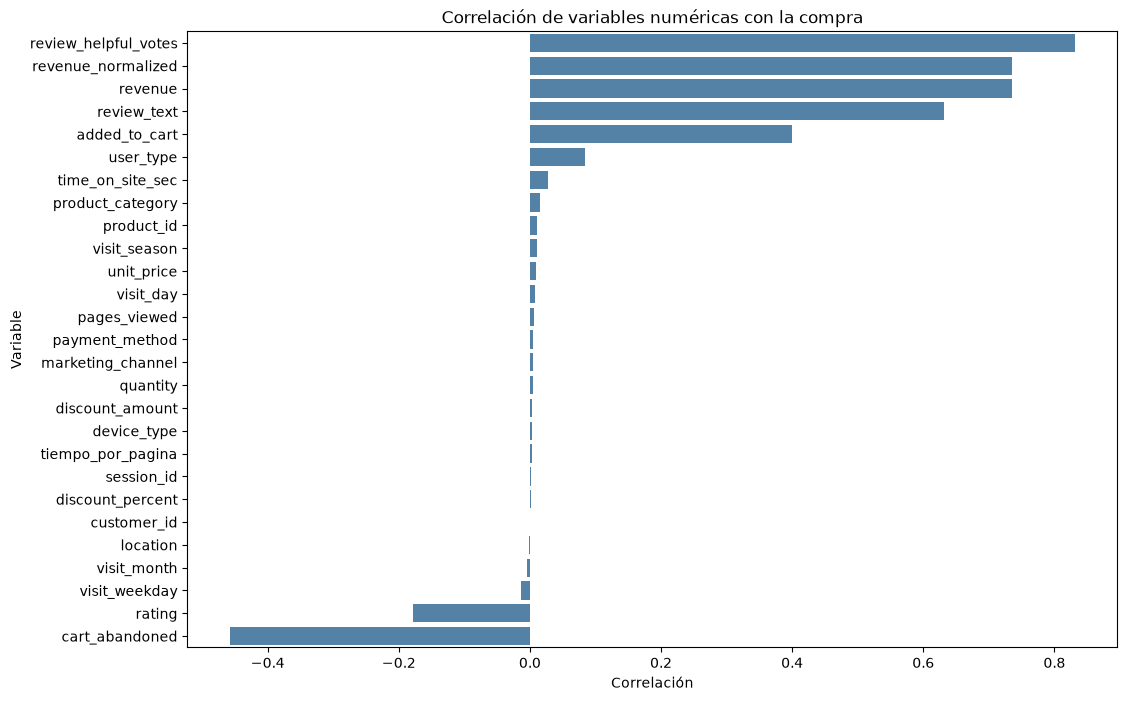

In [29]:
# Correlación de las variables numéricas con la variable objetivo
correlacion_target = (
    data.select_dtypes(include="number")
    .corr()[TARGET]
    .drop(TARGET)
)

# Ordenamos desde la correlación más negativa hasta la más positiva
correlacion_target = correlacion_target.sort_values(ascending=False)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=correlacion_target.values,
    y=correlacion_target.index,
    color="steelblue"
)

plt.title("Correlación de variables numéricas con la compra")
plt.xlabel("Correlación")
plt.ylabel("Variable")
plt.show()

## Variables con posible fuga de información

Para el modelado posterior se deben revisar variables que podrían no estar disponibles antes de conocer el resultado de la compra.

Variables a tratar con cuidado:

- `revenue`: solo existe si hubo compra.
- `revenue_normalized`: deriva de revenue.
- `cart_abandoned`: describe si una sesión terminó con carrito abandonado.
- `visit_day`, `visit_month`, `visit_weekday`, `visit_season`: pueden usarse si representan información conocida al momento de la sesión.
- `rating`, `review_text` y `review_helpful_votes`: deben revisarse porque podrían representar información posterior a la compra o información histórica del producto.

Esta revisión es importante para evitar entrenar un modelo con información que en un escenario real no estaría disponible al momento de predecir.

## Dataset preliminar para modelado

A partir del EDA, se puede dejar una primera propuesta de variables candidatas para modelar intención de compra.  
Esta selección puede ajustarse en la etapa de ingeniería de características.

In [30]:
variables_candidatas_modelo = [
    "device_type",
    "user_type",
    "marketing_channel",
    "product_category",
    "unit_price",
    "quantity",
    "discount_percent",
    "discount_amount",
    "pages_viewed",
    "time_on_site_sec",
    "added_to_cart",
    "rating",
    "payment_method",
    "visit_month",
    "visit_weekday",
    "visit_season",
    "session_duration_bucket",
    "location",
    "tiempo_por_pagina"
]

variables_a_excluir_por_leakage = [
    "revenue",
    "revenue_normalized",
    "cart_abandoned"
]

print("Variables candidatas para modelado:")
print(variables_candidatas_modelo)

print("\nVariables a excluir o revisar por posible leakage:")
print(variables_a_excluir_por_leakage)

Variables candidatas para modelado:
['device_type', 'user_type', 'marketing_channel', 'product_category', 'unit_price', 'quantity', 'discount_percent', 'discount_amount', 'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'rating', 'payment_method', 'visit_month', 'visit_weekday', 'visit_season', 'session_duration_bucket', 'location', 'tiempo_por_pagina']

Variables a excluir o revisar por posible leakage:
['revenue', 'revenue_normalized', 'cart_abandoned']


## Conclusiones preliminares

- El dataset contiene 25.000 sesiones de e-commerce con información útil sobre navegación, carrito, descuentos, producto, pago y compra.
- La variable `purchased` permite plantear un problema de clasificación para predecir intención de compra.
- Los KPIs principales del proyecto son la tasa de conversión y la tasa de abandono de carrito.
- Las variables relacionadas con carrito, descuento, navegación y categoría de producto pueden ser especialmente relevantes para diseñar promociones personalizadas.
- Algunas variables deben revisarse antes del modelado para evitar fuga de información, especialmente `revenue`, `revenue_normalized` y `cart_abandoned`.
- El análisis permite avanzar hacia un modelo predictivo que estime la probabilidad de compra y luego traduzca esa probabilidad en acciones comerciales personalizadas.

## Próximos pasos

1. Definir con precisión las variables que estarán disponibles antes de la compra.
2. Preparar el dataset para modelado.
3. Codificar variables categóricas.
4. Entrenar modelos de clasificación para predecir `purchased`.
5. Evaluar el modelo con métricas adecuadas para negocio.
6. Definir reglas de promociones personalizadas según probabilidad de compra, carrito y segmento de usuario.